In [3]:
import sys
import time
import serial
import  glob
from jii_multispeq.measurement import measure
import jii_multispeq.device as device
from matplotlib import pyplot as plt
import numpy as np

In [5]:
# Function to find the connected devices on available serial ports
def findDevice(question="hello", answer="", flush=True, timeout=5):
    """
    Attempts to find Ambit on any available serial port by sending 
    a 'question' string and looking for an 'answer' substring in the response.
    If no matching device is found on any port, implicitly return None

    :param question: The message to send to the device (default: "hello").
    :param answer: The substring we expect in the device's response (default: "").
    :param flush: Whether to flush the serial buffer before sending the question (default: True).
    :param timeout: The read timeout for the serial port in seconds (default: 1).
    :return: The port where the expected 'answer' is found, or None if not found.
    """
    
    def serial_ports():
        """ Lists serial port names

            :raises EnvironmentError:
                On unsupported or unknown platforms
            :returns:
                A list of the serial ports available on the system
        """
        if sys.platform.startswith('win'):
            ports = ['COM%s' % (i + 1) for i in range(256)]
        elif sys.platform.startswith('linux') or sys.platform.startswith('cygwin'):
            # this excludes your current terminal "/dev/tty"
            ports = glob.glob('/dev/tty[A-Za-z]*')
        elif sys.platform.startswith('darwin'):
            ports = glob.glob('/dev/tty.*')
        else:
            raise EnvironmentError('Unsupported platform')

        result = []
        for port in ports:
            try:
                s = serial.Serial(port)
                s.close()
                result.append(port)
            except (OSError, serial.SerialException):
                pass
        return result
    
    for port in serial_ports():     # Iterate through each potential serial port returned by 'serial_ports()'
        with serial.Serial(port, baudrate=115200, timeout=timeout) as ser:         # Open the serial port using a context manager to ensure it closes automatically
            # If flush is True, clear any existing data in the buffer 
            # and give a short delay to stabilize
            if flush:
                #ser.flush()
                ser.reset_input_buffer()
                time.sleep(0.5)
        
            ser.write(question.encode()) # Encode and write the 'question' to the serial port
            time.sleep(0.5) # Allow some time for the device to respond
            
            msg = ser.readline().decode(encoding='unicode_escape') # Read one line of response from the serial port, then decode it
            
            # If the expected 'answer' substring is in the device response, 
            # print and return the port
            print(f"Received message: {msg.strip()}")
            if answer in msg:
                print(f"Found device at: {port}, answer: {msg}")
                return port
    print("No matching device found.")
    return None  # If no matching device is found, return None
def find_in_tree(obj, *, match_key=None, match_value=None,
                 exist_key=None, return_key=None):
    """
    Search nested lists/dicts.
    - If match_key & match_value are set: collect return_key (or whole dict) from dicts where dict[match_key] == match_value.
    - If exist_key is set: collect return_key (or the value) from dicts that contain exist_key (useful for 'user_answers').
    """
    out = []
    if isinstance(obj, dict):
        # Equality match: e.g., label == "PIRK"
        if match_key is not None and obj.get(match_key) == match_value:
            out.append(obj.get(return_key) if return_key else obj)

        # Presence match: e.g., has key "user_answers"
        if exist_key is not None and exist_key in obj:
            val = obj[exist_key]
            if return_key is None:
                out.append(val)
            elif isinstance(val, dict):
                out.append(val.get(return_key))
            else:
                out.append(None)  # exist_key isn't a dict, can't take return_key

        # Recurse
        for v in obj.values():
            out.extend(find_in_tree(v, match_key=match_key, match_value=match_value,
                                    exist_key=exist_key, return_key=return_key))
    elif isinstance(obj, list):
        for it in obj:
            out.extend(find_in_tree(it, match_key=match_key, match_value=match_value,
                                    exist_key=exist_key, return_key=return_key))
    return out   

In [6]:
# Initialize ports for MiniPAR
PORT_MINIPAR = findDevice(question="hello\n",answer="MiniPAR",flush=True,timeout=2)

Received message: BAD COMMAND
Received message: MiniPAR,V1.1
Found device at: /dev/ttyACM0, answer: MiniPAR,V1.1



In [4]:
# Initialize ports for DC supply
PORT_DC_SOURCE = findDevice(question="*IDN?\n", answer="KIPRIM", flush=True, timeout=2)

Received message: 
Received message: unknown command
Received message: KIPRIM,DC310S,25011669,FV:V5.2.0
Found device at: /dev/ttyUSB0, answer: KIPRIM,DC310S,25011669,FV:V5.2.0



In [10]:
# Initialize ports for Ambit
PORT_AMBIT = findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)
PORT_AMBIT = findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)




Received message: BAD COMMAND
Received message: MiniPAR,V1.1
Received message: 
No matching device found.
Received message: NEW Name Here Ready
Found device at: /dev/ttyACM2, answer: NEW Name Here Ready



In [11]:
def set_voltage(port, voltage):
    with serial.Serial(port, baudrate=115200) as ser:
        ser.flush()
        msg = f"voltage {voltage:.3f}\r\n".encode()
        ser.write(msg)

set_voltage(port=PORT_DC_SOURCE, voltage= 25.0)

def set_current(port, current):
    with serial.Serial(port, baudrate=115200) as ser:
        ser.flush()
        msg = f"current {current:.3f}\r\n".encode()
        ser.write(msg)
set_current(port=PORT_DC_SOURCE, current=0.0)


In [12]:
# read mini Par
def get_par_MP(port, raw=False):
    with serial.Serial(port, baudrate=115200) as ser:
        ser.flush()
        if raw:
            ser.write("par_raw\n".encode())
        else:
            ser.write("par\n".encode())
        r = ser.readline()
        #print(r)

        return float(r.decode().strip())
        #print(r)


# read ambit PAR
def get_par_AMB(_PORT_AMBIT, raw=False):
    with serial.Serial(_PORT_AMBIT, baudrate=115200) as ser:
        ser.flush()
        if raw:
            ser.write("get_par\n".encode())
        else:
            ser.write("PAR\n".encode())
        r = ser.readline().decode(encoding='unicode_escape')
        #print(r)
        #r = ser.readline().decode(encoding='unicode_escape')
        #print(r)
        return float(r)
        #print(r))


        #r = ser.readline().decode(encoding='unicode_escape')

print(get_par_MP(PORT_MINIPAR))
print(get_par_AMB(PORT_AMBIT, raw = True))



3.31
8.41


In [ ]:
class AmbitInfo:
    def __init__(self):
        self.FW = ""
        self.light_slope = 0.0
        self.IsValid = False
        self.name = ""
        self.act_led_coeff = 0.0
    def processInfo(self, line):
        if b"FW:" in line and b"MAC" not in line:
            self.FW = line.split(b":")[1].strip()
        if b"Spec:" in line:
            self.light_slope = float(line.split(b"Spec:")[1].split(b'\t')[0].strip())
            self.IsValid = True
        if b"Name:" in line:
            self.name = line.split(b"Name:")[1].split(b'\t')[0].strip()
        if b"Actinic:" in line:
            self.act_led_coeff = float(line.split(b"Actinic:")[1].split(b'\t')[0].strip())

    def __str__(self):
        return f"FW: {self.FW}, light_slope: {self.light_slope}, IsValid: {self.IsValid}, name: {self.name}, actinic gain: {self.act_led_coeff}"

def ambit_reboot(_PORT_AMBIT):
    info = AmbitInfo()

    with serial.Serial(_PORT_AMBIT, baudrate=115200) as ser:
        ser.flush()
        ser.write("hello\n".encode())
        resp = ser.readline()
        ser.write("hello\n".encode())
        resp = ser.readline()
        while b"NEW" not in resp:
            ser.write("hello\n".encode())
            resp = ser.readline()
            print("Response: " + resp.decode(encoding='unicode_escape'))

        ser.write("reboot\n".encode())

        # process ambit data
        for i in range(26):
            l = ser.readline()
            info.processInfo(l)
            print(l)
            if b"FW:" in l and b"MAC" not in l:
                info.IsValid = True
                break;
                
            
    with serial.Serial(_PORT_AMBIT, baudrate=115200) as ser:
        ser.flush()
        ser.write("hello\n".encode())
        r = ser.readline()
        ser.write("hello\n".encode())
        r = ser.readline()
        print(r)
    return info


info = ambit_reboot(PORT_AMBIT)
print(info)
#print(get_par_AMB(PORT_AMBIT))

#with serial.Serial(PORT_AMBIT, baudrate=115200) as ser:
#    ser.flush()
#    ser.write("clean_nvs\n".encode())
#    r = ser.readline()
#    print(r)
#set_par_gain(PORT_AMBIT, 1.0 )
#ambit_reboot(PORT_AMBIT)
#print(get_par_AMB(PORT_AMBIT))
#ambit_reboot(PORT_AMBIT)


b'ESP-ROM:esp32c3-api1-20210207\r\n'
b'Build:Feb  7 2021\r\n'
b'rst:0xc (RTC_SW_CPU_RST),boot:0xd (SPI_FAST_FLASH_BOOT)\r\n'
b'Saved PC:0x403819c4\r\n'
b'SPIWP:0xee\r\n'
b'mode:DIO, clock div:1\r\n'
b'load:0x3fcd5820,len:0x1144\r\n'
b'load:0x403cc710,len:0xad8\r\n'
b'load:0x403ce710,len:0x2f80\r\n'
b'entry 0x403cc710\r\n'
b'BOOT\r\n'
b'256221\r\n'
b'ADPD Found, chip version: 2\n'
b'Metadata: lon:1.000000\tlat:1.000000\talt:1.000000\ttime:0\tacc:1.000000\tvacc:1.000000\tinfo1:New_Ambit\tx:0.000000\ty:0.000000\tz:0.000000\n'
b'Calibration: Name:AmbitV002\tActinic:0.069200\tSpec:0.213800\tEmit:1.000000\tSun:1.000000\tTemp_offset:0.000000\tTemp_slope:1.000000\n'
b'Calibration: Act_50:5\tAct_100:4\tAct_150:3\tAct_200:2\tAct_250:1\n'
b'Calibration: ADPD: 0\t0\t0\t0\t0\t0\n'
b'MLX: 5831149\t78341288\t0\t6400\t4896330\t5831149\t65410872\t-52101520\t-38880532\t16384\t0\t10752\t10752\t69373024\t\n'
b'FW: MAC:4c564fa89110\tSize:539216\tDate:Mar 26 2025\n'
b'FW: 0.0.3\n'
b'NEW Name Here Ready\r\n'

In [14]:
#set_par_gain(PORT_AMBIT, 1.0 )
#ambit_reboot(PORT_AMBIT)
#print(get_par_AMB(PORT_AMBIT))


currents = [0.2, 0.4, 0.8, 1.0, 1.6, 0]
reference_data = []
sensor_data = []
for I in currents:
    set_current(port=PORT_DC_SOURCE, current=I)
    time.sleep(1.0)
    ref_val = get_par_MP(PORT_MINIPAR)
    sens_val = get_par_AMB(PORT_AMBIT, raw=True)
    reference_data.append(ref_val)
    sensor_data.append(sens_val)

[4, 10, 20, 90, 150, 0]
[74.07, 194.91, 408.13, 1351.82, 2199.82, 6.2]


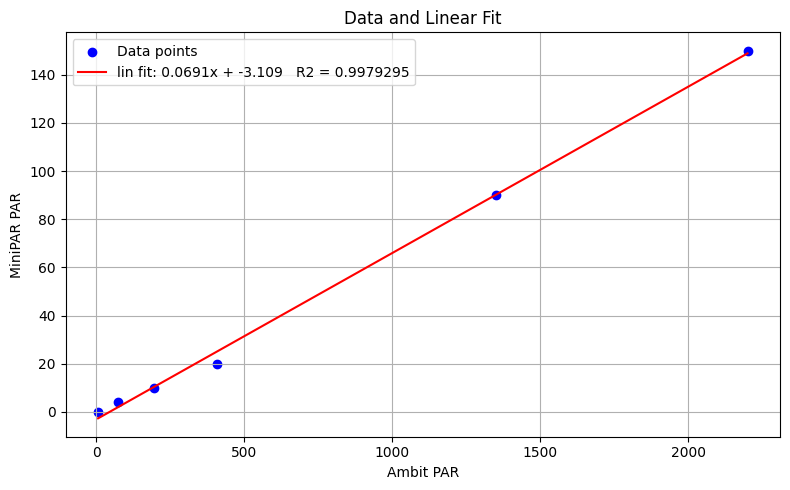

In [54]:
print(reference_data)
print(sensor_data)

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 1.0 if ss_res == 0 else 0.0
    return 1 - ss_res / ss_tot

def plot_data_and_fit(x, y, coeffs, r2, output=None, xlabel="x", ylabel="y"):
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color="blue", label="Data points")

    x_sort = np.linspace(np.min(x), np.max(x), 300)
    y_fit = np.polyval(coeffs, x_sort)
    plt.plot(x_sort, y_fit, color="red", label=f"lin fit: {coeffs[0]:.4g}x + {coeffs[1]:.4g}   R2 = {r2:.8g}")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Data and Linear Fit")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    if output:
        plt.savefig(output)
        print(f"Saved plot to {output}")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

y = reference_data
x = sensor_data
coeffs = np.polyfit(x, y, 1)
y_pred = np.polyval(coeffs, x)
r2 = r_squared(y, y_pred)

plot_data_and_fit(x,y, coeffs, r2, xlabel="Ambit PAR", ylabel="MiniPAR PAR")
#plt.plot(x, y, 'x')


In [16]:
# upload PAR callibration coefficients to the AMBYTE

slope = coeffs[0]
offset = coeffs[1]


def set_par_gain(_PORT_AMBIT, coeff):
    with serial.Serial(_PORT_AMBIT, baudrate=115200) as ser:
        ser.flush()
        resp = b""
        while b"NEW" not in resp:
            ser.write("hello\n".encode())
            resp = ser.readline()
            print("Response: " + resp.decode(encoding='unicode_escape'))
        
        
        msg = f"set_spec, {coeff:.4f}\n".encode()
        ser.write(msg)
        time.sleep(0.2)
        
        while b"NEW" not in resp:
            ser.write("hello\n".encode())
            resp = ser.readline()
            print("Response: " + resp.decode(encoding='unicode_escape'))
        return


set_par_gain(PORT_AMBIT, slope)
print('dssd')
info = ambit_reboot(PORT_AMBIT)

print(info)


set_current(port=PORT_DC_SOURCE, current=0.8)
time.sleep(1.0)

print(get_par_MP(port=PORT_MINIPAR))
print(get_par_AMB(PORT_AMBIT, raw=False))
#print(get_par_AMB(PORT_AMBIT, raw=True))
set_current(port=PORT_DC_SOURCE, current=0.0)

Response: NEW Name Here Ready

dssd
b'NEW Name Here Ready\r\n'
FW: b'0.0.3', light_slope: 0.2138, IsValid: True, name: b'AmbitV002'
80.1
79.66


In [17]:
set_current(port=PORT_DC_SOURCE, current=0.0)
print(info)

FW: b'0.0.3', light_slope: 0.2138, IsValid: True, name: b'AmbitV002'


In [28]:

def set_ambit_led(port, ledCurrent):
    with serial.Serial(port, baudrate=115200) as ser:
        ser.flush()
        resp = b""
        while b"NEW" not in resp:
            ser.write("hello\n".encode())
            resp = ser.readline()
            print("Response: " + resp.decode(encoding='unicode_escape'))
        
        
        msg = f"arrun1,1,0,2,0,0,1,0,1,{ledCurrent:d},1,\n, \n".encode()
        msg = f"arrun1,1,1,2,0,0,1,0,1,{ledCurrent:d},1,\n, \n".encode()
        ser.write(msg)
        time.sleep(0.2)
        
        while b"NEW" not in resp:
            ser.write("hello\n".encode())
            resp = ser.readline()
            print("Response: " + resp.decode(encoding='unicode_escape'))
        return

set_ambit_led(PORT_AMBIT, 2)
print(get_par_MP(PORT_MINIPAR))



Response: NEW Name Here Ready

7.87


In [76]:
currents = [  10, 20, 60, 90, 150, 0]
reference_data = []
sensor_data = []
for I in currents:
    set_ambit_led(PORT_AMBIT, I)
    time.sleep(0.2)
    sens_val = get_par_MP(PORT_MINIPAR)
    reference_data.append(I)
    sensor_data.append(sens_val)

    


Response: NEW Name Here Ready

Response: NEW Name Here Ready

Response: NEW Name Here Ready

Response: NEW Name Here Ready

Response: NEW Name Here Ready

Response: NEW Name Here Ready



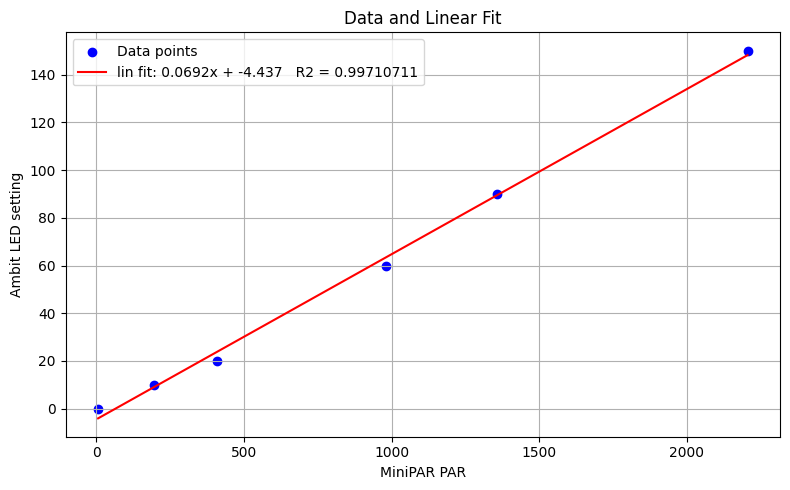

In [77]:
y = reference_data
x = sensor_data
coeffs = np.polyfit(x, y, 1)
y_pred = np.polyval(coeffs, x)
r2 = r_squared(y, y_pred)

plot_data_and_fit(x,y, coeffs, r2, ylabel="Ambit LED setting", xlabel="MiniPAR PAR")

In [83]:
print(info)

set_ambit_led_gain(PORT_AMBIT, coeffs[0])
info = ambit_reboot(PORT_AMBIT)
print(info)


def set_ambit_led_gain(port, coeff):
    with serial.Serial(port, baudrate=115200) as ser:
        ser.flush()
        resp = b""
        while b"NEW" not in resp:
            ser.write("hello\n".encode())
            resp = ser.readline()
            print("Response: " + resp.decode(encoding='unicode_escape'))
        
        
        msg = f"set_act, {coeff:.4f}\n".encode()
        ser.write(msg)
        time.sleep(0.2)
        
        while b"NEW" not in resp:
            ser.write("hello\n".encode())
            resp = ser.readline()
            print("Response: " + resp.decode(encoding='unicode_escape'))
        return


def set_ambit_something(port, coeff):
    with serial.Serial(port, baudrate=115200) as ser:
        ser.flush()
        resp = b""
        while b"NEW" not in resp:
            ser.write("hello\n".encode())
            resp = ser.readline()
            print("Response: " + resp.decode(encoding='unicode_escape'))
        
        
        msg = f"set_spec, {coeff:.4f}\n".encode()
        ser.write(msg)
        time.sleep(0.2)
        
        while b"NEW" not in resp:
            ser.write("hello\n".encode())
            resp = ser.readline()
            print("Response: " + resp.decode(encoding='unicode_escape'))
        return


FW: b'0.0.3', light_slope: 0.2138, IsValid: True, name: b'AmbitV002'
Response: NEW Name Here Ready

b'NEW Name Here Ready\r\n'
FW: b'0.0.3', light_slope: 0.2138, IsValid: True, name: b'AmbitV002'
